# Лабораторная работа №1

## Компьютерная лексикография, терминологические базы (TBX) и Translation Memory (TMX) в Smartcat

**ФИО студента:** Егоров Виталий Дмитриевич
**Группа:** ИНФА-221
**Вариант:** 2 (Кибербезопасность и защита информации)

---

**Цель:** научиться программно обрабатывать стандарты обмена терминологическими
данными (TBX) и памятью переводов (TMX), реализовать поиск нечётких совпадений
(Fuzzy Match) и подстановку терминов глоссария, экспортировать результат в
CAT-систему Smartcat.

**Порядок выполнения:**

1. Выполните ячейки Блока 1 (установка библиотек) и Блока 3 (демо-данные).
2. Реализуйте четыре функции в Блоке 4 вместо маркеров `# TODO`.
3. Запустите Блок 5 — все `assert` должны пройти без ошибок.
4. Соберите файлы своего варианта (Блок 6), экспортируйте CSV, оформите отчёт.

**Оценивание (10 баллов):** парсинг TBX — 2, парсинг TMX — 2, Fuzzy Match — 3,
интеграция глоссария — 2, оформление — 1.

## Блок 1. Setup — установка библиотек

In [85]:
!pip install -q Levenshtein pandas lxml

In [86]:
from __future__ import annotations

import os
import re
import unicodedata
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import pandas as pd

try:
    from lxml import etree as ET

    LXML_AVAILABLE = True
except ImportError:
    import xml.etree.ElementTree as ET

    LXML_AVAILABLE = False

try:
    import Levenshtein as _lev

    def edit_distance(a: str, b: str) -> int:
        """Расстояние Левенштейна между двумя строками."""
        return _lev.distance(a, b)

except ImportError:

    def edit_distance(a: str, b: str) -> int:
        """Расстояние Левенштейна (резервная реализация на чистом Python)."""
        if a == b:
            return 0
        if not a:
            return len(b)
        if not b:
            return len(a)
        previous = list(range(len(b) + 1))
        for i, char_a in enumerate(a, start=1):
            current = [i]
            for j, char_b in enumerate(b, start=1):
                current.append(min(previous[j] + 1,
                                   current[j - 1] + 1,
                                   previous[j - 1] + (char_a != char_b)))
            previous = current
        return previous[-1]


# ВАЖНО: атрибут xml:lang в парсере раскрывается в полное имя с пространством имён
XML_LANG = "{http://www.w3.org/XML/1998/namespace}lang"

pd.set_option("display.max_colwidth", 60)
print("Окружение готово. XML backend:", "lxml" if LXML_AVAILABLE else "ElementTree")

Окружение готово. XML backend: lxml


## Блок 2. Теория: структура стандартов

### 2.1. TBX (TermBase eXchange, ISO 30042)

Формат обмена терминологическими базами. Организован **по понятиям**
(concept-oriented): одна `termEntry` = одно понятие, внутри — по одной `langSet`
на каждый язык.

```xml
<martif type="TBX" xml:lang="en">
  <martifHeader>…</martifHeader>
  <text><body>
    <termEntry id="tid-001">
      <descrip type="subjectField">Предметная область</descrip>
      <langSet xml:lang="en">
        <tig>
          <term>flight controller</term>
          <termNote type="partOfSpeech">noun</termNote>
        </tig>
      </langSet>
      <langSet xml:lang="ru">
        <ntig><termGrp>
          <term>полётный контроллер</term>
        </termGrp></ntig>
      </langSet>
    </termEntry>
  </body></text>
</martif>
```

| Тег | Назначение |
|-----|------------|
| `martif` | корень документа TBX-Core v2 |
| `termEntry` | терминологическая статья (одно понятие) |
| `langSet` | языковая секция, язык задаётся атрибутом `xml:lang` |
| `tig` / `ntig` | компактная / расширенная группа термина |
| `term` | сам термин |
| `termNote` | грамматическая или иная помета (`partOfSpeech`, `usage`) |
| `descrip` | описание: `definition`, `subjectField`, `context` |

### 2.2. TMX (Translation Memory eXchange, версия 1.4b)

Формат обмена памятью переводов. Организован **по сегментам**.

```xml
<tmx version="1.4">
  <header srclang="en" segtype="sentence" datatype="plaintext"
          creationtool="…" adminlang="en" o-tmf="TMX"/>
  <body>
    <tu tuid="1">
      <prop type="domain">Aerospace</prop>
      <tuv xml:lang="en"><seg>The autopilot holds the altitude.</seg></tuv>
      <tuv xml:lang="ru"><seg>Автопилот выдерживает высоту.</seg></tuv>
    </tu>
  </body>
</tmx>
```

| Тег | Назначение |
|-----|------------|
| `header` | метаданные памяти: инструмент, язык оригинала, тип сегментации |
| `tu` | translation unit — единица перевода |
| `tuv` | translation unit variant — вариант на одном языке (`xml:lang`) |
| `seg` | текст сегмента |
| `prop` | произвольное свойство (`domain`, `client`, `project`) |

### 2.3. Типы совпадений в CAT-системах

| Совпадение | Диапазон | Действие переводчика |
|------------|----------|----------------------|
| ICE (101 %) | 100 % + совпал контекст | подстановка без правки |
| Exact | 100 % | проверить контекст |
| High Fuzzy | 95–99 % | косметическая правка |
| Fuzzy | 75–94 % | редактирование |
| No Match | < 75 % | перевод с нуля |

## Блок 3. Данные

Ячейка ниже создаёт **демонстрационные** файлы `demo.tbx` и `demo.tmx` — они
нужны только для автотестов из Блока 5. Файлы своего варианта
(`variant_2.tbx` — не менее 15 терминов, `variant_2.tmx` — не менее 10
предложений) вы создаёте в Блоке 6.

In [87]:
DEMO_TBX = """<?xml version="1.0" encoding="UTF-8"?>
<martif type="TBX" xml:lang="en">
  <martifHeader><fileDesc><titleStmt><title>Demo glossary</title></titleStmt>
  </fileDesc></martifHeader>
  <text><body>
    <termEntry id="tid-001">
      <descrip type="subjectField">Demo</descrip>
      <langSet xml:lang="en">
        <tig><term>flight controller</term>
        <termNote type="partOfSpeech">noun</termNote>
        <descrip type="definition">Onboard flight computer.</descrip></tig>
      </langSet>
      <langSet xml:lang="ru">
        <ntig><termGrp><term>полётный контроллер</term></termGrp></ntig>
      </langSet>
    </termEntry>
    <termEntry id="tid-002">
      <descrip type="subjectField">Demo</descrip>
      <langSet xml:lang="en"><tig><term>payload</term>
        <termNote type="partOfSpeech">noun</termNote></tig></langSet>
      <langSet xml:lang="ru"><ntig><termGrp><term>целевая нагрузка</term>
        </termGrp></ntig></langSet>
    </termEntry>
    <termEntry id="tid-003">
      <descrip type="subjectField">Demo</descrip>
      <langSet xml:lang="en"><tig><term>telemetry link</term></tig></langSet>
      <langSet xml:lang="ru"><ntig><termGrp><term>канал телеметрии</term>
        </termGrp></ntig></langSet>
    </termEntry>
  </body></text>
</martif>
"""

DEMO_TMX = """<?xml version="1.0" encoding="UTF-8"?>
<tmx version="1.4">
  <header creationtool="demo" creationtoolversion="1.0" segtype="sentence"
          o-tmf="TMX" adminlang="en" srclang="en" datatype="plaintext"/>
  <body>
    <tu tuid="1">
      <prop type="domain">Demo</prop>
      <tuv xml:lang="en"><seg>The flight controller stabilises the aircraft.</seg></tuv>
      <tuv xml:lang="ru"><seg>Полётный контроллер стабилизирует аппарат.</seg></tuv>
    </tu>
    <tu tuid="2">
      <prop type="domain">Demo</prop>
      <tuv xml:lang="en"><seg>The operator checks the telemetry link.</seg></tuv>
      <tuv xml:lang="ru"><seg>Оператор проверяет канал телеметрии.</seg></tuv>
    </tu>
    <tu tuid="3">
      <prop type="domain">Demo</prop>
      <tuv xml:lang="en"><seg>The payload is mounted under the fuselage.</seg></tuv>
      <tuv xml:lang="ru"><seg>Целевая нагрузка устанавливается под фюзеляжем.</seg></tuv>
    </tu>
  </body>
</tmx>
"""

with open("demo.tbx", "w", encoding="utf-8") as handler:
    handler.write(DEMO_TBX)
with open("demo.tmx", "w", encoding="utf-8") as handler:
    handler.write(DEMO_TMX)

print("Созданы файлы:", [f for f in os.listdir(".") if f.endswith((".tbx", ".tmx"))])

Созданы файлы: ['variant_2.tmx', 'demo.tbx', 'variant_2.tbx', 'demo.tmx']


## Блок 4. Задание — реализуйте четыре функции

Требования ко всем функциям: типизация из `typing`, соответствие PEP 8,
обработка отсутствующих элементов без падения (`None`-проверки).

**Подсказки:**

* язык секции читается как `element.get(XML_LANG)`, а не `element.get("lang")`;
* обход `<term>` внутри `langSet` удобно делать через `lang_set.iter("term")` —
  это покрывает и `tig`, и `ntig/termGrp`;
* текст сегмента лучше собирать через `"".join(seg.itertext())` — так не
  теряется текст при наличии инлайновых тегов;
* при подстановке терминов сортируйте их по убыванию длины.

In [88]:
def parse_tbx(file_path: str, src_lang: str = "en", tgt_lang: str = "ru") -> pd.DataFrame:
    """Разобрать TBX-глоссарий в плоскую таблицу терминологических пар."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Файл не найден: {file_path}")

    parser = ET.XMLParser(resolve_entities=False, load_dtd=False, no_network=True) \
        if LXML_AVAILABLE else None
    tree = ET.parse(file_path, parser) if parser else ET.parse(file_path)
    root = tree.getroot()

    rows: List[Dict[str, str]] = []
    for entry in root.iter("termEntry"):
        subject_node = entry.find("descrip[@type='subjectField']")
        subject_field = (subject_node.text or "").strip() if subject_node is not None else ""

        by_lang: Dict[str, Dict[str, str]] = {}
        for lang_set in entry.findall("langSet"):
            lang = (lang_set.get(XML_LANG) or "").split("-")[0].lower()
            terms = [t.text.strip() for t in lang_set.iter("term") if (t.text or "").strip()]
            if not terms:
                continue
            pos_node = lang_set.find(".//termNote[@type='partOfSpeech']")
            def_node = lang_set.find(".//descrip[@type='definition']")
            by_lang[lang] = {
                "term": terms[0],
                "pos": (pos_node.text or "").strip() if pos_node is not None else "",
                "definition": (def_node.text or "").strip() if def_node is not None else "",
            }

        if src_lang in by_lang and tgt_lang in by_lang:
            rows.append({
                "entry_id": entry.get("id", ""),
                "source_term": by_lang[src_lang]["term"],
                "target_term": by_lang[tgt_lang]["term"],
                "pos": by_lang[src_lang]["pos"] or by_lang[tgt_lang]["pos"],
                "definition": by_lang[src_lang]["definition"],
                "subject_field": subject_field,
            })

    return pd.DataFrame(rows, columns=["entry_id", "source_term", "target_term",
                                       "pos", "definition", "subject_field"])


def parse_tmx(file_path: str, src_lang: str = "en", tgt_lang: str = "ru") -> pd.DataFrame:
    """Разобрать TMX-память переводов в таблицу параллельных сегментов."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Файл не найден: {file_path}")

    parser = ET.XMLParser(resolve_entities=False, load_dtd=False, no_network=True) \
        if LXML_AVAILABLE else None
    tree = ET.parse(file_path, parser) if parser else ET.parse(file_path)
    root = tree.getroot()

    def _seg_text(tuv) -> str:
        seg = tuv.find("seg")
        if seg is None:
            return ""
        return re.sub(r"\s+", " ", "".join(seg.itertext())).strip()

    rows: List[Dict[str, Any]] = []
    for order, tu in enumerate(root.iter("tu"), start=1):
        segments: Dict[str, str] = {}
        for tuv in tu.findall("tuv"):
            lang = (tuv.get(XML_LANG) or tuv.get("lang") or "").split("-")[0].lower()
            text = _seg_text(tuv)
            if lang and text:
                segments[lang] = text

        if src_lang not in segments or tgt_lang not in segments:
            continue

        domain_node = tu.find("prop[@type='domain']")
        rows.append({
            "tuid": tu.get("tuid", str(order)),
            "source_segment": segments[src_lang],
            "target_segment": segments[tgt_lang],
            "domain": (domain_node.text or "").strip() if domain_node is not None else "",
            "src_len": len(segments[src_lang]),
        })

    frame = pd.DataFrame(rows, columns=["tuid", "source_segment", "target_segment",
                                        "domain", "src_len"])
    frame["prev_source"] = frame["source_segment"].shift(1).fillna("")
    return frame


def calculate_fuzzy_match(source_query: str, tm_df: pd.DataFrame,
                          threshold: float = 70.0,
                          context_before: Optional[str] = None,
                          top_n: int = 5) -> List[Dict[str, Any]]:
    """Найти в памяти переводов сегменты, похожие на запрос."""
    if tm_df is None or tm_df.empty or not source_query:
        return []

    def _classify(score: float, ctx_ok: bool) -> str:
        if score >= 100.0:
            return "ICE (101%)" if ctx_ok else "Exact (100%)"
        if score >= 95.0:
            return "High Fuzzy"
        if score >= 75.0:
            return "Fuzzy"
        return "Low Fuzzy"

    norm_query = normalize(source_query)
    results: List[Dict[str, Any]] = []

    for _, row in tm_df.iterrows():
        candidate = row["source_segment"]
        norm_cand = normalize(candidate)
        lev = levenshtein_ratio(norm_query, norm_cand)
        tsr = token_sort_ratio(source_query, candidate)
        score = max(lev, tsr)
        if score < threshold:
            continue

        ctx_matched = bool(
            context_before is not None
            and normalize(context_before) == normalize(str(row.get("prev_source", "")))
        )
        results.append({
            "tuid": row["tuid"],
            "source_segment": candidate,
            "target_segment": row["target_segment"],
            "score": round(score, 2),
            "lev_ratio": round(lev, 2),
            "token_sort_ratio": round(tsr, 2),
            "match_type": _classify(score, ctx_matched),
        })

    results.sort(key=lambda item: (item["score"], str(item["tuid"])), reverse=True)
    return results[:top_n]


def apply_term_glossary(text: str, glossary_df: pd.DataFrame,
                        template: str = "{source} [{target}]") -> str:
    """Разметить исходный текст переводными эквивалентами из глоссария."""
    if glossary_df is None or glossary_df.empty or not text:
        return text

    pairs = sorted(
        zip(glossary_df["source_term"], glossary_df["target_term"]),
        key=lambda pair: len(str(pair[0])),
        reverse=True,
    )

    protected: List[str] = []

    def _store(replacement: str) -> str:
        protected.append(replacement)
        return f"\x00{len(protected) - 1}\x00"

    result = text
    for source_term, target_term in pairs:
        source_term = str(source_term)
        if not source_term:
            continue
        pattern = re.compile(rf"(?<!\w){re.escape(source_term)}(?!\w)", re.IGNORECASE)
        result = pattern.sub(
            lambda match: _store(template.format(source=match.group(0), target=target_term)),
            result,
        )

    return re.sub(r"\x00(\d+)\x00", lambda m: protected[int(m.group(1))], result)


def glossary_coverage(text: str, glossary_df: pd.DataFrame) -> List[str]:
    """Вернуть список терминов глоссария, найденных в тексте."""
    found: List[str] = []
    for term in glossary_df["source_term"]:
        if re.search(rf"(?<!\w){re.escape(term)}(?!\w)", text, re.IGNORECASE):
            found.append(term)
    return found

### 4.1. Вспомогательные функции (реализуйте при необходимости)

Эти функции не оцениваются отдельно, но нужны для `calculate_fuzzy_match`.

In [89]:
_PUNCT_RE = re.compile(r"[^\w\s]", re.UNICODE)


def normalize(text: str) -> str:
    """Нормализовать строку: NFKC, нижний регистр, без пунктуации, одиночные пробелы."""
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text).lower().replace("ё", "е")
    text = _PUNCT_RE.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


def levenshtein_ratio(a: str, b: str) -> float:
    """Процент сходства строк на основе расстояния Левенштейна."""
    if not a and not b:
        return 100.0
    longest = max(len(a), len(b))
    if longest == 0:
        return 100.0
    return round((1.0 - edit_distance(a, b) / longest) * 100.0, 2)


def token_sort_ratio(a: str, b: str) -> float:
    """Процент сходства при игнорировании порядка слов."""
    sorted_a = " ".join(sorted(normalize(a).split()))
    sorted_b = " ".join(sorted(normalize(b).split()))
    return levenshtein_ratio(sorted_a, sorted_b)

def similarity(a: str, b: str) -> Dict[str, float]:
    """Вернуть словарь метрик сходства: ``lev``, ``token_sort``, ``score``."""
    norm_a, norm_b = normalize(a), normalize(b)
    lev = levenshtein_ratio(norm_a, norm_b)
    tsr = token_sort_ratio(a, b)
    return {"lev": lev, "token_sort": tsr, "score": max(lev, tsr)}

## Блок 5. Автотесты

Запустите ячейки ниже **после** реализации функций. Все проверки должны
завершиться без `AssertionError`. Тесты работают на демо-файлах из Блока 3.

In [90]:
# --- Тест 1: метрики сходства -------------------------------------------
assert abs(levenshtein_ratio("telemetry", "telemetry") - 100.0) < 1e-6, \
    "Одинаковые строки должны давать 100 %"
assert levenshtein_ratio("", "") == 100.0, "Две пустые строки — 100 %"
assert 0.0 <= levenshtein_ratio("payload", "airframe") < 50.0, \
    "Непохожие строки должны давать низкий процент"
assert abs(token_sort_ratio("angle of attack", "attack of angle") - 100.0) < 1e-6, \
    "Token Sort Ratio должен игнорировать порядок слов"
assert normalize("  Angle   OF ATTACK, critical! ") == "angle of attack critical", \
    "normalize: нижний регистр, без пунктуации, одиночные пробелы"
print("Тест 1 (метрики сходства) — OK")

Тест 1 (метрики сходства) — OK


In [91]:
# --- Тест 2: парсинг TBX -------------------------------------------------
glossary_df = parse_tbx("demo.tbx")

assert isinstance(glossary_df, pd.DataFrame), "parse_tbx должен вернуть DataFrame"
assert len(glossary_df) == 3, f"Ожидается 3 термина, получено {len(glossary_df)}"
for column in ["entry_id", "source_term", "target_term", "pos",
               "definition", "subject_field"]:
    assert column in glossary_df.columns, f"Нет колонки '{column}'"

row = glossary_df.loc[glossary_df["source_term"] == "flight controller"].iloc[0]
assert row["target_term"] == "полётный контроллер", "Неверный русский эквивалент"
assert row["entry_id"] == "tid-001", "Не извлечён атрибут id у termEntry"
assert row["pos"] == "noun", "Не извлечён termNote[@type='partOfSpeech']"
assert "telemetry link" in set(glossary_df["source_term"]), \
    "Термин из <tig> без termNote должен быть извлечён"
print("Тест 2 (парсинг TBX) — OK")
glossary_df.head()

Тест 2 (парсинг TBX) — OK


,entry_id,source_term,target_term,pos,definition,subject_field
0,tid-001,flight controller,полётный контроллер,noun,Onboard flight computer.,Demo
1,tid-002,payload,целевая нагрузка,noun,,Demo
2,tid-003,telemetry link,канал телеметрии,,,Demo


In [92]:
# --- Тест 3: парсинг TMX -------------------------------------------------
tm_df = parse_tmx("demo.tmx")

assert isinstance(tm_df, pd.DataFrame), "parse_tmx должен вернуть DataFrame"
assert len(tm_df) == 3, f"Ожидается 3 единицы перевода, получено {len(tm_df)}"
for column in ["tuid", "source_segment", "target_segment", "domain",
               "src_len", "prev_source"]:
    assert column in tm_df.columns, f"Нет колонки '{column}'"

first = tm_df.iloc[0]
assert first["source_segment"].startswith("The flight controller"), \
    "Не извлечён текст <seg> исходного языка"
assert first["target_segment"].startswith("Полётный контроллер"), \
    "Не извлечён текст <seg> языка перевода"
assert first["prev_source"] == "", "У первой строки prev_source должен быть пустым"
assert tm_df.iloc[1]["prev_source"] == first["source_segment"], \
    "prev_source должен содержать предыдущий исходный сегмент"
assert first["src_len"] == len(first["source_segment"]), "Неверная длина сегмента"
print("Тест 3 (парсинг TMX) — OK")
tm_df.head()

Тест 3 (парсинг TMX) — OK


,tuid,source_segment,target_segment,domain,src_len,prev_source
0,1,The flight controller stabilises the aircraft.,Полётный контроллер стабилизирует аппарат.,Demo,46,
1,2,The operator checks the telemetry link.,Оператор проверяет канал телеметрии.,Demo,39,The flight controller stabilises the aircraft.
2,3,The payload is mounted under the fuselage.,Целевая нагрузка устанавливается под фюзеляжем.,Demo,42,The operator checks the telemetry link.


In [93]:
# --- Тест 4: Fuzzy Match и ICE ------------------------------------------
exact_query = "The operator checks the telemetry link."
matches = calculate_fuzzy_match(exact_query, tm_df, threshold=70.0)
assert matches, "Точное совпадение обязано быть найдено"
assert abs(matches[0]["score"] - 100.0) < 1e-6, "Точное совпадение — 100 %"
assert matches[0]["match_type"] == "Exact (100%)", \
    "Без контекста 100 % — это Exact, а не ICE"

ice = calculate_fuzzy_match(
    exact_query, tm_df, threshold=70.0,
    context_before="The flight controller stabilises the aircraft.")
assert ice[0]["match_type"] == "ICE (101%)", \
    "При совпадении предыдущего сегмента 100 % должно стать ICE"

fuzzy = calculate_fuzzy_match("The engineer checks the telemetry link.",
                              tm_df, threshold=70.0)
assert fuzzy, "Похожий сегмент должен попадать в выдачу"
assert 75.0 <= fuzzy[0]["score"] < 100.0, \
    f"Ожидается Fuzzy 75–99 %, получено {fuzzy[0]['score']}"
assert fuzzy[0]["match_type"] in {"Fuzzy", "High Fuzzy"}, "Неверный тип совпадения"

scores = [m["score"] for m in calculate_fuzzy_match("telemetry link check",
                                                    tm_df, threshold=0.0)]
assert scores == sorted(scores, reverse=True), \
    "Результаты должны быть отсортированы по убыванию сходства"
assert calculate_fuzzy_match("Совершенно посторонний текст про бухгалтерию.",
                             tm_df, threshold=75.0) == [], \
    "Ниже порога результатов быть не должно"
assert len(calculate_fuzzy_match("telemetry", tm_df, threshold=0.0, top_n=2)) <= 2, \
    "Параметр top_n не учитывается"
print("Тест 4 (Fuzzy Match и ICE) — OK")

Тест 4 (Fuzzy Match и ICE) — OK


In [94]:
# --- Тест 5: подстановка терминов ---------------------------------------
marked = apply_term_glossary("The flight controller reads the payload status.",
                             glossary_df)
assert "[полётный контроллер]" in marked, "Термин из глоссария не подставлен"
assert "[целевая нагрузка]" in marked, "Подставлен не каждый найденный термин"
assert "flight controller" in marked, "Исходный термин должен сохраняться"

assert apply_term_glossary("No terms here at all.", glossary_df) == \
    "No terms here at all.", "Текст без терминов не должен меняться"

case_test = apply_term_glossary("Payload mass is 2 kg.", glossary_df)
assert "Payload [целевая нагрузка]" in case_test, \
    "Поиск должен быть регистронезависимым, а регистр текста — сохраняться"

assert "[целевая нагрузка]" not in apply_term_glossary("payloads are heavy",
                                                       glossary_df), \
    "Совпадение должно быть по границам слов, а не по подстроке"
print("Тест 5 (подстановка терминов) — OK")
print(marked)

Тест 5 (подстановка терминов) — OK
The flight controller [полётный контроллер] reads the payload [целевая нагрузка] status.


## Блок 6. Работа со своим вариантом

Вариант 2 — Кибербезопасность и защита информации. Термины взяты из ISO/IEC 27000:2018 и ГОСТ 33707-2016.

In [95]:
VARIANT = 2
SURNAME = "Egorov"
SUBJECT_FIELD = "Кибербезопасность и защита информации"

TBX_FILE = f"variant_{VARIANT}.tbx"
TMX_FILE = f"variant_{VARIANT}.tmx"

TERMS: List[Dict[str, str]] = [
    {"en": "access control", "ru": "управление доступом", "pos": "noun",
     "def_en": "means to ensure that access to assets is authorized and restricted based on business and security requirements"},
    {"en": "attack", "ru": "атака", "pos": "noun",
     "def_en": "attempt to destroy, expose, alter, disable, steal or gain unauthorized access to or make unauthorized use of an asset"},
    {"en": "audit", "ru": "аудит", "pos": "noun",
     "def_en": "systematic, independent and documented process for obtaining audit evidence and evaluating it objectively to determine the extent to which the audit criteria are fulfilled"},
    {"en": "audit scope", "ru": "область аудита", "pos": "noun",
     "def_en": "extent and boundaries of an audit"},
    {"en": "authentication", "ru": "аутентификация", "pos": "noun",
     "def_en": "provision of assurance that a claimed characteristic of an entity is correct"},
    {"en": "authenticity", "ru": "подлинность", "pos": "noun",
     "def_en": "property that an entity is what it claims to be"},
    {"en": "availability", "ru": "доступность", "pos": "noun",
     "def_en": "property of being accessible and usable on demand by an authorized entity"},
    {"en": "base measure", "ru": "основной показатель", "pos": "noun",
     "def_en": "measure defined in terms of an attribute and the method for quantifying it"},
    {"en": "competence", "ru": "компетентность", "pos": "noun",
     "def_en": "ability to apply knowledge and skills to achieve intended results"},
    {"en": "confidentiality", "ru": "конфиденциальность", "pos": "noun",
     "def_en": "property that information is not made available or disclosed to unauthorized individuals, entities, or processes"},
    {"en": "conformity", "ru": "соответствие", "pos": "noun",
     "def_en": "fulfilment of a requirement"},
    {"en": "consequence", "ru": "последствие", "pos": "noun",
     "def_en": "outcome of an event affecting objectives"},
    {"en": "continual improvement", "ru": "постоянное улучшение", "pos": "noun",
     "def_en": "recurring activity to enhance performance"},
    {"en": "control", "ru": "средство управления", "pos": "noun",
     "def_en": "measure that is modifying risk"},
    {"en": "control objective", "ru": "цель управления", "pos": "noun",
     "def_en": "statement describing what is to be achieved as a result of implementing controls"},
    {"en": "correction", "ru": "коррекция", "pos": "noun",
     "def_en": "action to eliminate a detected nonconformity"},
    {"en": "corrective action", "ru": "корректирующее действие", "pos": "noun",
     "def_en": "action to eliminate the cause of a nonconformity and to prevent recurrence"},
    {"en": "derived measure", "ru": "производный показатель", "pos": "noun",
     "def_en": "measure that is defined as a function of two or more values of base measures"},
    {"en": "documented information", "ru": "документированная информация", "pos": "noun",
     "def_en": "information required to be controlled and maintained by an organization and the medium on which it is contained"},
    {"en": "effectiveness", "ru": "результативность", "pos": "noun",
     "def_en": "extent to which planned activities are realized and planned results achieved"},
    {"en": "event", "ru": "событие", "pos": "noun",
     "def_en": "occurrence or change of a particular set of circumstances"},
    {"en": "external context", "ru": "внешний контекст", "pos": "noun",
     "def_en": "external environment in which the organization seeks to achieve its objectives"},
    {"en": "governance of information security", "ru": "управление информационной безопасностью", "pos": "noun",
     "def_en": "system by which an organization's information security activities are directed and controlled"},
    {"en": "governing body", "ru": "руководящий орган управления", "pos": "noun",
     "def_en": "person or group of people who are accountable for the performance and conformity of the organization"},
    {"en": "indicator", "ru": "индикатор", "pos": "noun",
     "def_en": "measure that provides an estimate or evaluation"},
    {"en": "information need", "ru": "информационная потребность", "pos": "noun",
     "def_en": "insight necessary to manage objectives, goals, risks and problems"},
    {"en": "information processing facilities", "ru": "средства обработки информации", "pos": "noun",
     "def_en": "any information processing system, service or infrastructure, or the physical location housing it"},
    {"en": "information security", "ru": "информационная безопасность", "pos": "noun",
     "def_en": "preservation of confidentiality, integrity and availability of information"},
    {"en": "information security continuity", "ru": "непрерывность информационной безопасности", "pos": "noun",
     "def_en": "processes and procedures for ensuring continued information security operations"},
    {"en": "information security event", "ru": "событие информационной безопасности", "pos": "noun",
     "def_en": "identified occurrence of a system, service or network state indicating a possible breach of information security policy or failure of controls"},
    {"en": "information security incident", "ru": "инцидент информационной безопасности", "pos": "noun",
     "def_en": "single or a series of unwanted or unexpected information security events that have a significant probability of compromising business operations"},
    {"en": "information security incident management", "ru": "менеджмент инцидентов информационной безопасности", "pos": "noun",
     "def_en": "set of processes for detecting, reporting, assessing, responding to, dealing with, and learning from information security incidents"},
    {"en": "information security management system professional", "ru": "профессионал системы менеджмента информационной безопасности", "pos": "noun",
     "def_en": "person who establishes, implements, maintains and continuously improves one or more information security management system processes"},
    {"en": "information sharing community", "ru": "сообщество обмена информацией", "pos": "noun",
     "def_en": "group of organizations that agree to share information"},
    {"en": "information system", "ru": "информационная система", "pos": "noun",
     "def_en": "set of applications, services, information technology assets, or other information-handling components"},
    {"en": "integrity", "ru": "целостность", "pos": "noun",
     "def_en": "property of accuracy and completeness"},
    {"en": "interested party", "ru": "заинтересованная сторона", "pos": "noun",
     "def_en": "person or organization that can affect, be affected by, or perceive itself to be affected by a decision or activity"},
    {"en": "internal context", "ru": "внутренний контекст", "pos": "noun",
     "def_en": "internal environment in which the organization seeks to achieve its objectives"},
    {"en": "level of risk", "ru": "уровень риска", "pos": "noun",
     "def_en": "magnitude of a risk expressed in terms of the combination of consequences and their likelihood"},
    {"en": "likelihood", "ru": "вероятность", "pos": "noun",
     "def_en": "chance of something happening"},
    {"en": "management system", "ru": "система менеджмента", "pos": "noun",
     "def_en": "set of interrelated or interacting elements of an organization to establish policies and objectives and processes to achieve those objectives"},
    {"en": "measure", "ru": "показатель", "pos": "noun",
     "def_en": "variable to which a value is assigned as the result of measurement"},
    {"en": "measurement", "ru": "измерение", "pos": "noun",
     "def_en": "process to determine a value"},
    {"en": "measurement function", "ru": "функция расчета производного показателя", "pos": "noun",
     "def_en": "algorithm or calculation performed to combine two or more base measures"},
    {"en": "measurement method", "ru": "метод измерения", "pos": "noun",
     "def_en": "logical sequence of operations, described generically, used in quantifying an attribute with respect to a specified scale"},
    {"en": "monitoring", "ru": "мониторинг", "pos": "noun",
     "def_en": "determining the status of a system, a process or an activity"},
    {"en": "nonconformity", "ru": "несоответствие", "pos": "noun",
     "def_en": "non-fulfilment of a requirement"},
    {"en": "non-repudiation", "ru": "неопровержимость авторства", "pos": "noun",
     "def_en": "ability to prove the occurrence of a claimed event or action and its originating entities"},
    {"en": "objective", "ru": "задача", "pos": "noun",
     "def_en": "result to be achieved"},
    {"en": "organization", "ru": "организация", "pos": "noun",
     "def_en": "person or group of people that has its own functions with responsibilities, authorities and relationships to achieve its objectives"},
    {"en": "outsource", "ru": "передавать на аутсорсинг", "pos": "verb",
     "def_en": "make an arrangement where an external organization performs part of an organization's function or process"},
    {"en": "performance", "ru": "показатель деятельности", "pos": "noun",
     "def_en": "measurable result"},
    {"en": "policy", "ru": "политика", "pos": "noun",
     "def_en": "intentions and direction of an organization, as formally expressed by its top management"},
    {"en": "process", "ru": "процесс", "pos": "noun",
     "def_en": "set of interrelated or interacting activities which transforms inputs into outputs"},
    {"en": "reliability", "ru": "надежность", "pos": "noun",
     "def_en": "property of consistent intended behaviour and results"},
    {"en": "requirement", "ru": "требование", "pos": "noun",
     "def_en": "need or expectation that is stated, generally implied or obligatory"},
    {"en": "residual risk", "ru": "остаточный риск", "pos": "noun",
     "def_en": "risk remaining after risk treatment"},
    {"en": "review", "ru": "анализ", "pos": "noun",
     "def_en": "activity undertaken to determine the suitability, adequacy and effectiveness of the subject matter to achieve established objectives"},
    {"en": "review object", "ru": "объект анализа", "pos": "noun",
     "def_en": "specific item being reviewed"},
    {"en": "review objective", "ru": "цель анализа", "pos": "noun",
     "def_en": "statement describing what is to be achieved as a result of a review"},
    {"en": "risk", "ru": "риск", "pos": "noun",
     "def_en": "effect of uncertainty on objectives"},
    {"en": "risk acceptance", "ru": "принятие риска", "pos": "noun",
     "def_en": "informed decision to take a particular risk"},
    {"en": "risk analysis", "ru": "анализ риска", "pos": "noun",
     "def_en": "process to comprehend the nature of risk and to determine the level of risk"},
    {"en": "risk assessment", "ru": "оценка риска", "pos": "noun",
     "def_en": "overall process of risk identification, risk analysis and risk evaluation"},
    {"en": "risk communication and consultation", "ru": "обмен информацией по рискам и консультации", "pos": "noun",
     "def_en": "set of continual and iterative processes that an organization conducts to provide, share or obtain information, and to engage in dialogue with stakeholders regarding the management of risk"},
    {"en": "risk criteria", "ru": "критерий риска", "pos": "noun",
     "def_en": "terms of reference against which the significance of risk is evaluated"},
    {"en": "risk evaluation", "ru": "определение степени риска", "pos": "noun",
     "def_en": "process of comparing the results of risk analysis with risk criteria to determine whether the risk and/or its magnitude is acceptable or tolerable"},
    {"en": "risk identification", "ru": "идентификация риска", "pos": "noun",
     "def_en": "process of finding, recognizing and describing risks"},
    {"en": "risk management", "ru": "менеджмент риска", "pos": "noun",
     "def_en": "coordinated activities to direct and control an organization with regard to risk"},
    {"en": "risk management process", "ru": "процесс менеджмента риска", "pos": "noun",
     "def_en": "systematic application of management policies, procedures and practices to the activities of communicating, consulting, establishing the context and identifying, analysing, evaluating, treating, monitoring and reviewing risk"},
    {"en": "risk owner", "ru": "владелец риска", "pos": "noun",
     "def_en": "person or entity with the accountability and authority to manage a risk"},
    {"en": "risk treatment", "ru": "обработка риска", "pos": "noun",
     "def_en": "process to modify risk"},
    {"en": "security implementation standard", "ru": "стандарт обеспечения безопасности", "pos": "noun",
     "def_en": "document specifying authorized ways for realizing security"},
    {"en": "threat", "ru": "угроза", "pos": "noun",
     "def_en": "potential cause of an unwanted incident, which can result in harm to a system or organization"},
    {"en": "top management", "ru": "высшее руководство", "pos": "noun",
     "def_en": "person or group of people who directs and controls an organization at the highest level"},
    {"en": "trusted information communication entity", "ru": "доверенный участник информационного сообщества", "pos": "noun",
     "def_en": "autonomous organization supporting information exchange within an information sharing community"},
    {"en": "vulnerability", "ru": "уязвимость", "pos": "noun",
     "def_en": "weakness of an asset or control that can be exploited by one or more threats"},
    {"en": "sensitivity", "ru": "важность", "pos": "noun",
     "def_en": "measure of importance assigned to information by the information owner to denote its need for protection"},
    {"en": "abbreviated address calling", "ru": "вызов по сокращенному адресу", "pos": "noun",
      "def_en": "calling that enables a user to employ an address having fewer characters than the full address when initiating a call"},
    {"en": "character", "ru": "знак", "pos": "noun",
      "def_en": "member of a set of elements that is used for the representation, organization, or control of data"},
    {"en": "data", "ru": "данные", "pos": "noun",
     "def_en": "reinterpretable representation of information in a formalized manner suitable for communication, interpretation, or processing"},
    {"en": "edit", "ru": "редактирование", "pos": "noun",
     "def_en": "prepare data for a later operation"},
    {"en": "facsimile", "ru": "факсимиле", "pos": "noun",
     "def_en": "transmission over a telecommunication system of images of pages and the creation of copies of those images at the receiving location"},
    {"en": "gateway", "ru": "шлюз", "pos": "noun",
     "def_en": "functional unit that connects two computer networks having different network architectures"},
    {"en": "hash function", "ru": "хэш-функция", "pos": "noun",
     "def_en": "function used to determine the position of a given item in a set of items"},
    {"en": "icon", "ru": "пиктограмма", "pos": "noun",
     "def_en": "graphic symbol, displayed on a screen, to which a user can point with a device, such as a mouse, in order to select a particular function or software application"},
    {"en": "job", "ru": "задание", "pos": "noun",
     "def_en": "unit of work that is defined by a user and that is to be accomplished by a computer"},
    {"en": "kernel", "ru": "ядро", "pos": "noun",
     "def_en": "that part of a control program that is resident in main storage"},
    {"en": "label", "ru": "метка", "pos": "noun",
     "def_en": "identifier for a location in a program"},
    {"en": "machine learning", "ru": "машинное обучение", "pos": "noun",
     "def_en": "process by which a functional unit improves its performance by acquiring new knowledge or skills, or by reorganizing existing knowledge or skills"},
    {"en": "node", "ru": "узел", "pos": "noun",
     "def_en": "in a network, entity that is connected to one or more other entities"},
    {"en": "object code", "ru": "объектный код", "pos": "noun",
     "def_en": "final version of code prior to execution"},
    {"en": "packet", "ru": "пакет", "pos": "noun",
     "def_en": "sequence of bits arranged in a specific format, containing control data and possibly user data, and that is transmitted and switched as a whole"},
    {"en": "queue", "ru": "очередь", "pos": "noun",
     "def_en": "list that is constructed and maintained so that the next item to be retrieved is the one inserted earliest"},
    {"en": "router", "ru": "маршрутизатор", "pos": "noun",
     "def_en": "functional unit that establishes a path through one or more computer networks"},
    {"en": "scanner", "ru": "сканирующее устройство", "pos": "noun",
     "def_en": "device that examines a special pattern, one part after another, and generates analog or digital signals corresponding to the pattern"},
    {"en": "table", "ru": "таблица", "pos": "noun",
     "def_en": "arrangement of data in which each item may be identified by means of arguments or keys"},
    {"en": "upload", "ru": "загрузка", "pos": "noun",
     "def_en": "transfer programs or data from a connected computer to a computer with greater resources, typically from a personal computer to a mainframe"},
    {"en": "virtual machine", "ru": "виртуальная машина", "pos": "noun",
     "def_en": "virtual data processing system that appears to be at the exclusive disposal of a particular user, but whose functions are accomplished by sharing the resources of a real data processing system"},
    {"en": "workstation", "ru": "рабочая станция", "pos": "noun",
     "def_en": "functional unit that usually has special purpose computing capabilities and includes user-oriented input units and output units"}
]

print(f"Загружено терминов: {len(TERMS)}")
assert len(TERMS) == 100, f"Должно быть 100 терминов, а не {len(TERMS)}"

Загружено терминов: 100


### 6.1. Генерация `variant_2.tbx` (TBX-Core v2)

Функция `build_tbx()` преобразует список терминов в валидный TBX-файл:
английские секции — через `<tig>`, русские — через `<ntig><termGrp>`.

In [96]:
def indent_tree(element, level: int = 0, space: str = "  ") -> None:
    """Рекурсивно расставить отступы в XML-дереве."""
    pad = "\n" + space * level
    if len(element):
        if not (element.text or "").strip():
            element.text = pad + space
        for child in element:
            indent_tree(child, level + 1, space)
        if not (element.tail or "").strip():
            element.tail = pad
        if not (element[-1].tail or "").strip():
            element[-1].tail = pad
    elif level and not (element.tail or "").strip():
        element.tail = pad


def build_tbx(terms: Sequence[Dict[str, str]], path: str,
              subject_field: str = SUBJECT_FIELD) -> str:
    """Сгенерировать валидный TBX-файл (TBX-Core v2, martif)."""
    martif = ET.Element("martif", {"type": "TBX", XML_LANG: "en"})

    header = ET.SubElement(martif, "martifHeader")
    file_desc = ET.SubElement(header, "fileDesc")
    title_stmt = ET.SubElement(file_desc, "titleStmt")
    ET.SubElement(title_stmt, "title").text = f"Glossary EN-RU: {subject_field}"
    source_desc = ET.SubElement(file_desc, "sourceDesc")
    ET.SubElement(source_desc, "p").text = "Lab 01, variant 2, ISO 27000 + GOST 33707"
    encoding_desc = ET.SubElement(header, "encodingDesc")
    ET.SubElement(encoding_desc, "p", {"type": "XCSURI"}).text = "TBXXCSV02.xcs"

    body = ET.SubElement(ET.SubElement(martif, "text"), "body")

    for index, item in enumerate(terms, start=1):
        entry = ET.SubElement(body, "termEntry", {"id": f"tid-{index:03d}"})
        ET.SubElement(entry, "descrip", {"type": "subjectField"}).text = subject_field

        lang_en = ET.SubElement(entry, "langSet", {XML_LANG: "en"})
        tig = ET.SubElement(lang_en, "tig")
        ET.SubElement(tig, "term").text = item["en"]
        ET.SubElement(tig, "termNote", {"type": "partOfSpeech"}).text = item["pos"]
        ET.SubElement(tig, "descrip", {"type": "definition"}).text = item["def_en"]

        lang_ru = ET.SubElement(entry, "langSet", {XML_LANG: "ru"})
        term_grp = ET.SubElement(ET.SubElement(lang_ru, "ntig"), "termGrp")
        ET.SubElement(term_grp, "term").text = item["ru"]
        ET.SubElement(term_grp, "termNote", {"type": "partOfSpeech"}).text = item["pos"]

    indent_tree(martif)
    xml_body = ET.tostring(martif, encoding="unicode")
    with open(path, "w", encoding="utf-8") as handler:
        handler.write('<?xml version="1.0" encoding="UTF-8"?>\n')
        handler.write('<!DOCTYPE martif SYSTEM "TBXcoreStructV02.dtd">\n')
        handler.write(xml_body)
    return path


build_tbx(TERMS, TBX_FILE)
print(f"Создан {TBX_FILE}: {os.path.getsize(TBX_FILE)} байт, терминов: {len(TERMS)}\n")
print("--- первые 26 строк файла ---")
with open(TBX_FILE, encoding="utf-8") as handler:
    for line in list(handler)[:26]:
        print(line.rstrip())

Создан variant_2.tbx: 74393 байт, терминов: 100

--- первые 26 строк файла ---
<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE martif SYSTEM "TBXcoreStructV02.dtd">
<martif type="TBX" xml:lang="en">
  <martifHeader>
    <fileDesc>
      <titleStmt>
        <title>Glossary EN-RU: Кибербезопасность и защита информации</title>
      </titleStmt>
      <sourceDesc>
        <p>Lab 01, variant 2, ISO 27000 + GOST 33707</p>
      </sourceDesc>
    </fileDesc>
    <encodingDesc>
      <p type="XCSURI">TBXXCSV02.xcs</p>
    </encodingDesc>
  </martifHeader>
  <text>
    <body>
      <termEntry id="tid-001">
        <descrip type="subjectField">Кибербезопасность и защита информации</descrip>
        <langSet xml:lang="en">
          <tig>
            <term>access control</term>
            <termNote type="partOfSpeech">noun</termNote>
            <descrip type="definition">means to ensure that access to assets is authorized and restricted based on business and security requirements</descrip>
  

### 6.2. Генерация `variant_2.tmx` (TMX 1.4b)

Память переводов на 100 сегментов. Каждое предложение содержит хотя бы один
термин из глоссария TBX.

In [97]:
PARALLEL_CORPUS: List[Tuple[str, str]] = [
    ("Access control ensures that access to assets is authorized and restricted.",
     "Управление доступом гарантирует, что доступ к активам авторизован и ограничен."),
    ("An attack is an attempt to destroy, expose, alter, disable or steal an asset.",
     "Атака — это попытка уничтожить, раскрыть, изменить, вывести из строя или украсть актив."),
    ("The audit is a systematic and documented process for obtaining audit evidence.",
     "Аудит — это систематический и документированный процесс получения свидетельства аудита."),
    ("The audit scope defines the extent and boundaries of an audit.",
     "Область аудита определяет объем и границы аудита."),
    ("Authentication provides assurance that a claimed characteristic of an entity is correct.",
     "Аутентификация обеспечивает гарантию того, что заявленная характеристика объекта является подлинной."),
    ("Authenticity is the property that an entity is what it claims to be.",
     "Подлинность — это свойство, указывающее, что объект представляет собой то, что он заявляет о себе."),
    ("Availability is the property of being accessible and usable on demand by an authorized entity.",
     "Доступность — это свойство быть доступным и готовым к использованию по запросу авторизованного объекта."),
    ("A base measure is defined in terms of an attribute and the method for quantifying it.",
     "Основной показатель определяется через атрибут и метод его количественной оценки."),
    ("Competence is the ability to apply knowledge and skills to achieve intended results.",
     "Компетентность — это способность применять знания и навыки для достижения желаемых результатов."),
    ("Confidentiality means that information is not disclosed to unauthorized individuals.",
     "Конфиденциальность означает, что информация не раскрывается неавторизованным лицам."),
    ("Conformity means fulfilment of a requirement.",
     "Соответствие означает выполнение требования."),
    ("A consequence is the outcome of an event affecting objectives.",
     "Последствие — это результат события, оказывающий влияние на цели."),
    ("Continual improvement is a recurring activity to enhance performance.",
     "Постоянное улучшение — это повторяющаяся деятельность по улучшению показателей деятельности."),
    ("A control is a measure that modifies risk.",
     "Средство управления — это мера, которая изменяет риск."),
    ("A control objective describes what is to be achieved as a result of implementing controls.",
     "Цель управления описывает, что должно быть достигнуто в результате применения средств управления."),
    ("Correction is an action to eliminate a detected nonconformity.",
     "Коррекция — это действие для устранения обнаруженного несоответствия."),
    ("Corrective action eliminates the cause of a nonconformity and prevents recurrence.",
     "Корректирующее действие устраняет причину несоответствия и предотвращает его повторение."),
    ("A derived measure is defined as a function of two or more values of base measures.",
     "Производный показатель определяется как функция двух или более значений основных показателей."),
    ("Documented information must be controlled and maintained by the organization.",
     "Документированная информация должна управляться и поддерживаться организацией."),
    ("Effectiveness is the extent to which planned activities are realized and planned results achieved.",
     "Результативность — это степень, с которой запланированные задачи выполнены и запланированные результаты достигнуты."),
    ("An event is an occurrence or change of a particular set of circumstances.",
     "Событие — это возникновение или изменение определенного набора обстоятельств."),
    ("The external context is the external environment in which the organization seeks to achieve its objectives.",
     "Внешний контекст — это внешняя среда, в которой организация стремится достичь своих целей."),
    ("Governance of information security directs and controls information security activities.",
     "Управление информационной безопасностью направляет и контролирует действия в сфере информационной безопасности."),
    ("The governing body is accountable for the performance and conformity of the organization.",
     "Руководящий орган управления несет ответственность за показатели деятельности и соответствие организации."),
    ("An indicator is a measure that provides an estimate or evaluation.",
     "Индикатор — это показатель, который представляет собой прогнозную или вычисляемую оценку."),
    ("Information need is the insight necessary to manage objectives, goals, risks and problems.",
     "Информационная потребность — это осознаваемая необходимость управления задачами, целями, рисками и проблемами."),
    ("Information processing facilities include any information processing system or service.",
     "Средства обработки информации включают любую систему обработки информации или службу."),
    ("Information security preserves the confidentiality, integrity and availability of information.",
     "Информационная безопасность обеспечивает сохранение конфиденциальности, целостности и доступности информации."),
    ("Information security continuity ensures continued information security operations.",
     "Непрерывность информационной безопасности гарантирует постоянное обеспечение информационной безопасности."),
    ("An information security event indicates a possible breach of information security policy.",
     "Событие информационной безопасности указывает на возможное нарушение политики информационной безопасности."),
    ("An information security incident is a single or a series of unwanted information security events.",
     "Инцидент информационной безопасности — это одно или последовательность нежелательных событий информационной безопасности."),
    ("Information security incident management detects, reports and responds to incidents.",
     "Менеджмент инцидентов информационной безопасности обеспечивает обнаружение, информирование и реагирование на инциденты."),
    ("An information security management system professional establishes and improves ISMS processes.",
     "Профессионал системы менеджмента информационной безопасности разрабатывает и улучшает процессы СМИБ."),
    ("An information sharing community is a group of organizations that agree to share information.",
     "Сообщество обмена информацией — это группа организаций, которые достигли соглашения о совместном использовании информации."),
    ("An information system is a set of applications, services and information technology assets.",
     "Информационная система — это совокупность приложений, служб и ИТ-активов."),
    ("Integrity is the property of accuracy and completeness.",
     "Целостность — это свойство сохранения полноты и точности."),
    ("An interested party can affect or be affected by a decision or activity.",
     "Заинтересованная сторона может влиять на решения или действия или быть подвержена их влиянию."),
    ("The internal context is the internal environment in which the organization seeks to achieve its objectives.",
     "Внутренний контекст — это внутренняя среда, в которой организация стремится достичь своих задач."),
    ("The level of risk is the magnitude of a risk expressed in terms of consequences and likelihood.",
     "Уровень риска — это величина риска, выраженная комбинацией последствий и их вероятности."),
    ("Likelihood is the chance of something happening.",
     "Вероятность — это возможность того, что что-то произойдет."),
    ("A management system is a set of interrelated elements to establish policies and objectives.",
     "Система менеджмента — это совокупность взаимосвязанных элементов для разработки политик и задач."),
    ("A measure is a variable to which a value is assigned as the result of measurement.",
     "Показатель — это переменная, значение которой присваивается в результате измерения."),
    ("Measurement is a process to determine a value.",
     "Измерение — это процесс определения значения."),
    ("A measurement function is an algorithm performed to combine base measures.",
     "Функция расчета производного показателя — это алгоритм, выполняемый для объединения основных показателей."),
    ("A measurement method is a logical sequence of operations used in quantifying an attribute.",
     "Метод измерения — это логическая последовательность действий для количественного определения атрибута."),
    ("Monitoring is determining the status of a system, a process or an activity.",
     "Мониторинг — это определение состояния системы, процесса или задачи."),
    ("Nonconformity is non-fulfilment of a requirement.",
     "Несоответствие — это невыполнение требования."),
    ("Non-repudiation is the ability to prove the occurrence of a claimed event or action.",
     "Неопровержимость авторства — это возможность доказать наступление оспариваемого события или действия."),
    ("An objective is a result to be achieved.",
     "Задача — это результат, который должен быть достигнут."),
    ("An organization is a person or group of people with its own functions and responsibilities.",
     "Организация — это лицо или группа лиц, наделенные своими собственными функциями и обязанностями."),
    ("To outsource means an external organization performs part of an organization's function.",
     "Передавать на аутсорсинг означает, что внешняя организация выполняет часть функций организации."),
    ("Performance is a measurable result.",
     "Показатель деятельности — это измеримый результат."),
    ("A policy is the intentions and direction of an organization, formally expressed by top management.",
     "Политика — это намерения и направление развития организации, официально сформулированные высшим руководством."),
    ("A process is a set of interrelated activities which transforms inputs into outputs.",
     "Процесс — это совокупность взаимосвязанных видов деятельности, которая преобразует входы в выходы."),
    ("Reliability is the property of consistent intended behaviour and results.",
     "Надежность — это свойство соответствия предполагаемому поведению и результатам."),
    ("A requirement is a need or expectation that is stated, implied or obligatory.",
     "Требование — это потребность или ожидание, которое установлено, подразумевается или является обязательным."),
    ("Residual risk is the risk remaining after risk treatment.",
     "Остаточный риск — это риск, оставшийся после обработки риска."),
    ("A review determines the suitability, adequacy and effectiveness of the subject matter.",
     "Анализ определяет пригодность, адекватность и результативность объекта анализа."),
    ("A review object is a specific item being reviewed.",
     "Объект анализа — это конкретный объект, подвергаемый анализу."),
    ("A review objective describes what is to be achieved as a result of a review.",
     "Цель анализа описывает, что должно быть достигнуто в результате анализа."),
    ("Risk is the effect of uncertainty on objectives.",
     "Риск — это влияние неопределенности на цели."),
    ("Risk acceptance is an informed decision to take a particular risk.",
     "Принятие риска — это обоснованное решение согласиться с конкретным риском."),
    ("Risk analysis is a process to comprehend the nature of risk and to determine the level of risk.",
     "Анализ риска — это процесс понимания характера риска и определения уровня риска."),
    ("Risk assessment is the overall process of risk identification, analysis and evaluation.",
     "Оценка риска — это единый процесс идентификации риска, анализа риска и определения степени риска."),
    ("Risk communication and consultation involve dialogue with stakeholders regarding risk.",
     "Обмен информацией по рискам и консультации включают диалог с заинтересованными сторонами по вопросам риска."),
    ("Risk criteria are terms of reference against which the significance of risk is evaluated.",
     "Критерий риска — это эталонные условия, в сравнении с которыми оценивают значимость риска."),
    ("Risk evaluation compares the results of risk analysis with risk criteria.",
     "Определение степени риска сравнивает результаты анализа риска с критериями риска."),
    ("Risk identification is the process of finding, recognizing and describing risks.",
     "Идентификация риска — это процесс поиска, распознавания и описания рисков."),
    ("Risk management is coordinated activities to direct and control an organization with regard to risk.",
     "Менеджмент риска — это скоординированные действия по руководству и управлению организацией в отношении рисков."),
    ("The risk management process applies policies and procedures to risk activities.",
     "Процесс менеджмента риска применяет политики и процедуры к действиям по управлению риском."),
    ("A risk owner has the accountability and authority to manage a risk.",
     "Владелец риска обладает ответственностью и полномочиями для менеджмента риска."),
    ("Risk treatment is a process to modify risk.",
     "Обработка риска — это процесс, нацеленный на изменение риска."),
    ("A security implementation standard specifies authorized ways for realizing security.",
     "Стандарт обеспечения безопасности устанавливает разрешенные методы обеспечения безопасности."),
    ("A threat is a potential cause of an unwanted incident.",
     "Угроза — это возможная причина нежелательного инцидента."),
    ("Top management directs and controls an organization at the highest level.",
     "Высшее руководство направляет и управляет организацией на высшем уровне."),
    ("A trusted information communication entity supports information exchange within a community.",
     "Доверенный участник информационного сообщества поддерживает информационное взаимодействие в рамках сообщества."),
    ("A vulnerability is a weakness of an asset or control that can be exploited by threats.",
     "Уязвимость — это слабое место актива или средства управления, через которое может реализоваться угроза."),
    ("Access is obtaining the use of a resource.",
     "Доступ — это получение возможности использования ресурса."),
    ("An access right is permission for a subject to access a particular object.",
     "Право доступа — это разрешение субъекту на доступ к определенному объекту."),
    ("Authorization is the granting of rights, including access based on access rights.",
     "Санкционирование — это предоставление прав, включая предоставление доступа на основе прав доступа."),
    ("Cryptography embodies principles and methods for the transformation of data.",
     "Криптография воплощает принципы и методы преобразования данных."),
    ("Decryption is the process of obtaining original data from a ciphertext.",
     "Расшифрование — это процесс получения исходных данных из шифрограммы."),
    ("Encryption is the cryptographic transformation of data.",
     "Шифрование — это криптографическое преобразование данных."),
    ("Identity authentication enables a system to recognize entities.",
     "Аутентификация личности позволяет системе распознавать субъекты."),
    ("Logical access control uses mechanisms related to data to provide access control.",
     "Логическое управление доступом использует механизмы, связанные с данными, для обеспечения управления доступом."),
    ("Message authentication verifies that a message was sent by the purported originator.",
     "Аутентификация сообщения проверяет, что сообщение было отправлено заявленным отправителем."),
    ("A message authentication code is a function of data and a secret key.",
     "Код аутентификации сообщений — это функция данных и секретного ключа."),
    ("Physical access control uses physical mechanisms to provide access control.",
     "Физическое управление доступом использует физические механизмы для обеспечения управления доступом."),
    ("A private key is intended for decryption for the exclusive use by its owner.",
     "Закрытый ключ предназначен для расшифрования и используется исключительно его владельцем."),
    ("A public key is intended for use by any entity for encrypted communication.",
     "Открытый ключ предназначен для использования любой стороной для зашифрованной связи."),
    ("A secret key is intended for use by a limited number of correspondents.",
     "Секретный ключ предназначен для использования ограниченным числом корреспондентов."),
    ("A security audit is an independent review of data processing system records.",
     "Аудит безопасности — это независимая проверка документации системы обработки данных."),
    ("A security clearance is permission to access data at or below a particular security level.",
     "Разрешение безопасности — это разрешение на доступ к данным на определенном уровне безопасности или ниже."),
    ("A security filter enforces a security policy on the data that pass through it.",
     "Фильтр безопасности обеспечивает соблюдение политики безопасности для проходящих через него данных."),
    ("A security policy is a plan or course of action adopted for providing computer security.",
     "Политика безопасности — это план или способ действий по обеспечению компьютерной безопасности."),
    ("Sensitive information must be protected because its disclosure will cause perceivable damage.",
     "Конфиденциальная информация должна быть защищена, поскольку ее раскрытие причинит ощутимый ущерб."),
    ("A subject is an active entity that can access objects.",
     "Субъект доступа — это активный компонент системы, который может обращаться к объектам."),
    ("System integrity means the system fulfils its operational purpose securely.",
     "Целостность системы означает, что система безопасно выполняет свое операционное назначение."),
    ("A trusted computer system provides sufficient computer security for concurrent access.",
     "Доверенная компьютерная система обеспечивает достаточную компьютерную безопасность для параллельного доступа."),
    ("An identity token is a device used for identity authentication.",
     "Идентификационный маркер — это устройство, используемое для аутентификации личности."),
]

print(f"Загружено сегментов: {len(PARALLEL_CORPUS)}")
assert len(PARALLEL_CORPUS) >= 100, "Должно быть не менее 100 сегментов"


def build_tmx(pairs: Sequence[Tuple[str, str]], path: str,
              src_lang: str = "en", tgt_lang: str = "ru",
              domain: str = "Cybersecurity / Information security") -> str:
    """Сгенерировать валидную память переводов в формате TMX 1.4b."""
    from datetime import datetime, timezone
    created = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

    tmx = ET.Element("tmx", {"version": "1.4"})
    ET.SubElement(tmx, "header", {
        "creationtool": "lab01-generator",
        "creationtoolversion": "1.0",
        "segtype": "sentence",
        "o-tmf": "TMX",
        "adminlang": "en",
        "srclang": src_lang,
        "datatype": "plaintext",
        "creationdate": created,
    })
    body = ET.SubElement(tmx, "body")

    for index, (source, target) in enumerate(pairs, start=1):
        tu = ET.SubElement(body, "tu", {"tuid": str(index), "creationdate": created})
        ET.SubElement(tu, "prop", {"type": "domain"}).text = domain
        for lang, text in ((src_lang, source), (tgt_lang, target)):
            tuv = ET.SubElement(tu, "tuv", {XML_LANG: lang})
            ET.SubElement(tuv, "seg").text = text

    indent_tree(tmx)
    xml_body = ET.tostring(tmx, encoding="unicode")
    with open(path, "w", encoding="utf-8") as handler:
        handler.write('<?xml version="1.0" encoding="UTF-8"?>\n')
        handler.write('<!DOCTYPE tmx SYSTEM "tmx14.dtd">\n')
        handler.write(xml_body)
    return path


build_tmx(PARALLEL_CORPUS, TMX_FILE)
print(f"Создан {TMX_FILE}: {os.path.getsize(TMX_FILE)} байт, единиц перевода: {len(PARALLEL_CORPUS)}\n")
print("--- первые 20 строк файла ---")
with open(TMX_FILE, encoding="utf-8") as handler:
    for line in list(handler)[:20]:
        print(line.rstrip())

Загружено сегментов: 100
Создан variant_2.tmx: 48925 байт, единиц перевода: 100

--- первые 20 строк файла ---
<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE tmx SYSTEM "tmx14.dtd">
<tmx version="1.4">
  <header creationtool="lab01-generator" creationtoolversion="1.0" segtype="sentence" o-tmf="TMX" adminlang="en" srclang="en" datatype="plaintext" creationdate="20260924T124923Z"/>
  <body>
    <tu tuid="1" creationdate="20260924T124923Z">
      <prop type="domain">Cybersecurity / Information security</prop>
      <tuv xml:lang="en">
        <seg>Access control ensures that access to assets is authorized and restricted.</seg>
      </tuv>
      <tuv xml:lang="ru">
        <seg>Управление доступом гарантирует, что доступ к активам авторизован и ограничен.</seg>
      </tuv>
    </tu>
    <tu tuid="2" creationdate="20260924T124923Z">
      <prop type="domain">Cybersecurity / Information security</prop>
      <tuv xml:lang="en">
        <seg>An attack is an attempt to destroy, expose, alt

### 6.3. Парсинг данных варианта
Вывод первых 8 терминов из TBX на английском языке, перевод на русский язык, указание части речи слова.

In [98]:
my_glossary = parse_tbx(TBX_FILE)
my_tm = parse_tmx(TMX_FILE)

print(f"Терминов в TBX: {len(my_glossary)}")
print(f"Сегментов в TMX: {len(my_tm)}")

glossary_df = parse_tbx(TBX_FILE)
print(f"\nИзвлечено терминологических пар: {len(glossary_df)}")
glossary_df[["entry_id", "source_term", "target_term", "pos"]].head(8)

Терминов в TBX: 100
Сегментов в TMX: 100

Извлечено терминологических пар: 100


,entry_id,source_term,target_term,pos
0,tid-001,access control,управление доступом,noun
1,tid-002,attack,атака,noun
2,tid-003,audit,аудит,noun
3,tid-004,audit scope,область аудита,noun
4,tid-005,authentication,аутентификация,noun
5,tid-006,authenticity,подлинность,noun
6,tid-007,availability,доступность,noun
7,tid-008,base measure,основной показатель,noun


Вывод первых 5 сегментов из TMX на английском языке и их перевод на русский язык.

In [99]:
tm_df = parse_tmx(TMX_FILE)
print(f"Извлечено единиц перевода: {len(tm_df)}")
print(f"Средняя длина исходного сегмента: {tm_df['src_len'].mean():.1f} симв.")
tm_df[["tuid", "source_segment", "target_segment"]].head(5)

Извлечено единиц перевода: 100
Средняя длина исходного сегмента: 76.5 симв.


,tuid,source_segment,target_segment
0,1,Access control ensures that access to assets is authoriz...,"Управление доступом гарантирует, что доступ к активам ав..."
1,2,"An attack is an attempt to destroy, expose, alter, disab...","Атака — это попытка уничтожить, раскрыть, изменить, выве..."
2,3,The audit is a systematic and documented process for obt...,Аудит — это систематический и документированный процесс ...
3,4,The audit scope defines the extent and boundaries of an ...,Область аудита определяет объем и границы аудита.
4,5,Authentication provides assurance that a claimed charact...,"Аутентификация обеспечивает гарантию того, что заявленна..."


### 6.4. Три сценария: ICE, Fuzzy, No Match
Для проверки ICE подобраны предложения с сохранением контекста терминов.

Для проверки Fuzzy предложения немного изменены, но сохраняют суть терминов.

No Match — предложение не из сегментов TMX.

In [100]:
q_ice = "The audit is a systematic and documented process for obtaining audit evidence."
ctx_ice = "An attack is an attempt to destroy, expose, alter, disable or steal an asset."

q_fuzzy = "The security audit is a documented process for obtaining audit evidence."

q_nomatch = "The marketing team prepared a new promotional brochure for the product."

QUERIES = [
    {"label": "1. ICE — точное совпадение с совпадением контекста",
     "query": q_ice, "context": ctx_ice},
    {"label": "2. Fuzzy — заменены два слова",
     "query": q_fuzzy, "context": None},
    {"label": "3. No match — сегмент вне предметной области",
     "query": q_nomatch, "context": None},
]

all_matches: List[Dict[str, Any]] = []

for case in QUERIES:
    matches = calculate_fuzzy_match(case["query"], my_tm, threshold=70.0,
                                    context_before=case["context"], top_n=3)
    print("=" * 100)
    print(case["label"])
    print(f"Запрос: {case['query']}")
    if not matches:
        print("  -> совпадений выше порога 70 % не найдено, сегмент переводится с нуля")
        continue
    for rank, match in enumerate(matches, start=1):
        print(f"  #{rank} {match['score']:6.2f} %  [{match['match_type']:<12}] "
              f"tuid={match['tuid']}")
        print(f"      TM src: {match['source_segment']}")
        print(f"      TM tgt: {match['target_segment']}")
        match["query"] = case["query"]
        all_matches.append(match)

matches_df = pd.DataFrame(all_matches)
print("=" * 100)
print(f"\nВсего кандидатов выше порога: {len(matches_df)}")
matches_df[["query", "tuid", "score", "lev_ratio", "token_sort_ratio", "match_type"]].head(6)

1. ICE — точное совпадение с совпадением контекста
Запрос: The audit is a systematic and documented process for obtaining audit evidence.
  #1 100.00 %  [ICE (101%)  ] tuid=3
      TM src: The audit is a systematic and documented process for obtaining audit evidence.
      TM tgt: Аудит — это систематический и документированный процесс получения свидетельства аудита.
2. Fuzzy — заменены два слова
Запрос: The security audit is a documented process for obtaining audit evidence.
  #1  84.42 %  [Fuzzy       ] tuid=3
      TM src: The audit is a systematic and documented process for obtaining audit evidence.
      TM tgt: Аудит — это систематический и документированный процесс получения свидетельства аудита.
3. No match — сегмент вне предметной области
Запрос: The marketing team prepared a new promotional brochure for the product.
  -> совпадений выше порога 70 % не найдено, сегмент переводится с нуля

Всего кандидатов выше порога: 2


,query,tuid,score,lev_ratio,token_sort_ratio,match_type
0,The audit is a systematic and documented process for obt...,3,100.00,100.00,100.00,ICE (101%)
1,The security audit is a documented process for obtaining...,3,84.42,76.62,84.42,Fuzzy


График показывает распределение процента сходства запроса №2 со всеми сегментами ТМ — так работает ранжирование кандидатов внутри CAT-системы.

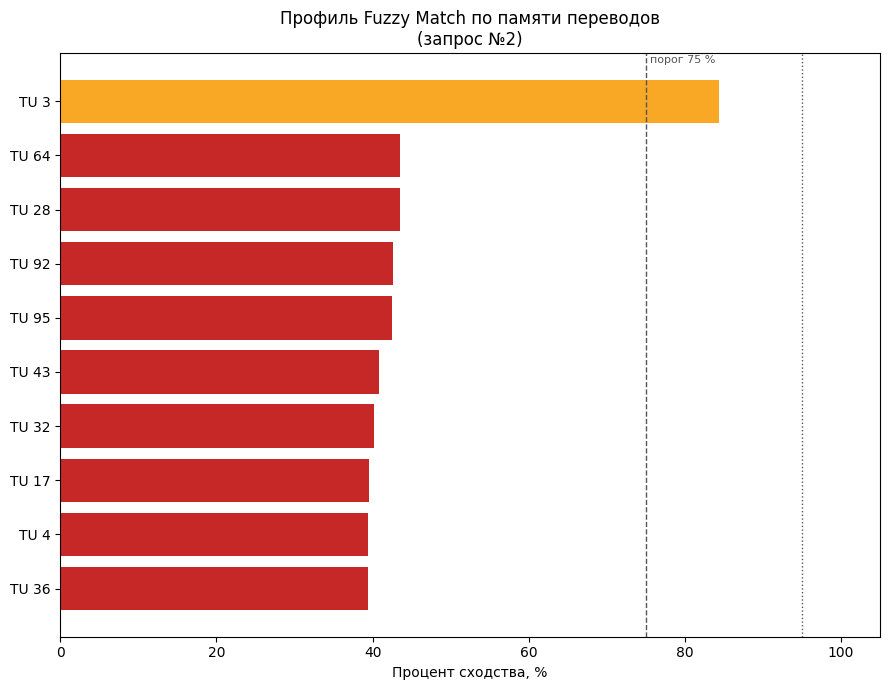

Максимум: 84.42 %   медиана: 29.58 %


In [101]:
probe = next(q["query"] for q in QUERIES if "Fuzzy" in q["label"])
scores = []
for seg in my_tm["source_segment"]:
    lev = levenshtein_ratio(normalize(probe), normalize(seg))
    tsr = token_sort_ratio(probe, seg)
    scores.append(round(max(lev, tsr), 2))

profile = (pd.DataFrame({"tuid": my_tm["tuid"], "score": scores})
           .sort_values("score", ascending=False)
           .reset_index(drop=True))

colors = ["#2e7d32" if v >= 95 else "#f9a825" if v >= 75 else "#c62828"
          for v in profile["score"]]

top = profile.head(10)
top_colors = colors[:10]

fig, axes = plt.subplots(figsize=(9, 7))
axes.barh([f"TU {t}" for t in top["tuid"]], top["score"], color=top_colors)
axes.axvline(75, color="#555555", linestyle="--", linewidth=1)
axes.axvline(95, color="#555555", linestyle=":",  linewidth=1)
axes.set_xlim(0, 105)
axes.set_xlabel("Процент сходства, %")
axes.set_title("Профиль Fuzzy Match по памяти переводов\n(запрос №2)")
axes.invert_yaxis()
axes.text(75.5, -0.7, "порог 75 %", fontsize=8, color="#555555")
fig.tight_layout()
plt.show()

print(f"Максимум: {max(scores):.2f} %   медиана: {pd.Series(scores).median():.2f} %")

### 6.5. Экспорт CSV для Smartcat и отчёта. Подстановка терминов глоссария
Smartcat импортирует глоссарии из CSV с заголовком вида Source (en); Target (ru); Comment. Память переводов загружается напрямую в формате .tmx.

In [102]:
import csv

GLOSSARY_CSV = f"glossary_smartcat.csv"
TM_CSV = f"tm_segments.csv"
FUZZY_CSV = f"fuzzy_report.csv"

smartcat_df = pd.DataFrame({
    "Source (en)": my_glossary["source_term"],
    "Target (ru)": my_glossary["target_term"],
    "Comment": my_glossary["definition"],
})
smartcat_df.to_csv(GLOSSARY_CSV, index=False, encoding="utf-8-sig",
                   sep=";", quoting=csv.QUOTE_ALL)

my_tm[["tuid", "source_segment", "target_segment", "domain"]].to_csv(
    TM_CSV, index=False, encoding="utf-8-sig")


report_rows = []
for label, query, ctx in [
    ("ICE", q_ice, ctx_ice),
    ("Fuzzy", q_fuzzy, None),
    ("NoMatch", q_nomatch, None),
]:
    matches = calculate_fuzzy_match(query, my_tm, threshold=70.0,
                                    context_before=ctx, top_n=1)
    if matches:
        m = matches[0]
        report_rows.append({
            "query": query, "tuid": m["tuid"],
            "source_segment": m["source_segment"],
            "target_segment": m["target_segment"],
            "score": m["score"], "match_type": m["match_type"],
        })
    else:
        report_rows.append({"query": query, "tuid": "-",
                            "source_segment": "-", "target_segment": "-",
                            "score": 0.0, "match_type": "No Match"})

pd.DataFrame(report_rows).to_csv(FUZZY_CSV, index=False, encoding="utf-8-sig")

DEMO_SEGMENTS = [
    "Access control and authentication protect confidentiality of documented information.",
    "An attack can compromise availability of the information system.",
    "The corrective action eliminates the cause of a nonconformity.",
]

for segment in DEMO_SEGMENTS:
    print("-" * 100)
    print(f"Исходный: {segment}")
    print(f"С подстановкой: {apply_term_glossary(segment, my_glossary)}")
print()

print("Экспортированные файлы:")
for name in [TBX_FILE, TMX_FILE, GLOSSARY_CSV, TM_CSV, FUZZY_CSV]:
    print(f"  {name:<30} {os.path.getsize(name):>7} байт")
print("\nПревью glossary_smartcat_v2.csv:")
smartcat_df.head(5)



----------------------------------------------------------------------------------------------------
Исходный: Access control and authentication protect confidentiality of documented information.
С подстановкой: Access control [управление доступом] and authentication [аутентификация] protect confidentiality [конфиденциальность] of documented information [документированная информация].
----------------------------------------------------------------------------------------------------
Исходный: An attack can compromise availability of the information system.
С подстановкой: An attack [атака] can compromise availability [доступность] of the information system [информационная система].
----------------------------------------------------------------------------------------------------
Исходный: The corrective action eliminates the cause of a nonconformity.
С подстановкой: The corrective action [корректирующее действие] eliminates the cause of a nonconformity [несоответствие].

Экспортиров

,Source (en),Target (ru),Comment
0,access control,управление доступом,means to ensure that access to assets is authorized and ...
1,attack,атака,"attempt to destroy, expose, alter, disable, steal or gai..."
2,audit,аудит,"systematic, independent and documented process for obtai..."
3,audit scope,область аудита,extent and boundaries of an audit
4,authentication,аутентификация,provision of assurance that a claimed characteristic of ...


###6.6.  Итоговая сводка по работе
Сводка показывает, что реализованный конвейер обработки CAT-данных работает полностью: от чтения стандартизированных форматов (TBX/TMX) через нечёткий поиск (Fuzzy Match, ICE) до интеграции глоссария и экспорта результатов. Все метрики имеют статус OK, ни один этап не выявил ошибок или недостатка данных. Полученные файлы (variant_2.tbx, variant_2.tmx, glossary_smartcat.csv, tm_segments.csv, fuzzy_report.csv). Ноутбук воспроизводит полный цикл работы переводчика с памятью переводов и терминологической базой. Цель лабораторной работы достигнута.

In [103]:
def glossary_coverage(text: str, glossary_df: pd.DataFrame) -> List[str]:

    found: List[str] = []
    for term in glossary_df["source_term"]:
        if re.search(rf"(?<!\w){re.escape(term)}(?!\w)", text, re.IGNORECASE):
            found.append(term)
    return found



tbx_entries = len(my_glossary)
tmx_entries = len(my_tm)


fuzzy_candidates = 0
ice_contexts = 0
for label, query, ctx in [
    ("ICE", q_ice, ctx_ice),
    ("Fuzzy", q_fuzzy, None),
    ("NoMatch", q_nomatch, None),
]:
    matches = calculate_fuzzy_match(query, my_tm, threshold=70.0,
                                    context_before=ctx, top_n=1)
    if matches:
        fuzzy_candidates += 1
        if matches[0]["match_type"] == "ICE (101%)":
            ice_contexts += 1


glossary_terms_substituted = sum(
    len(glossary_coverage(s, my_glossary)) for s in DEMO_SEGMENTS
)


summary = pd.DataFrame([
    {"Этап": "1. Парсинг и валидация TBX", "Метрика": "термостатей",
     "Значение": tbx_entries,
     "Статус": "OK" if tbx_entries >= 15 else "МАЛО ДАННЫХ"},
    {"Этап": "2. Парсинг TMX", "Метрика": "единиц перевода",
     "Значение": tmx_entries,
     "Статус": "OK" if tmx_entries >= 10 else "МАЛО ДАННЫХ"},
    {"Этап": "3. Fuzzy Match", "Метрика": "кандидатов выше порога",
     "Значение": fuzzy_candidates, "Статус": "OK"},
    {"Этап": "3. ICE", "Метрика": "контекстных совпадений",
     "Значение": ice_contexts, "Статус": "OK"},
    {"Этап": "4. Глоссарий", "Метрика": "терминов подставлено (демо)",
     "Значение": glossary_terms_substituted, "Статус": "OK"},
])

print(summary.to_string(index=False))

                      Этап                     Метрика  Значение Статус
1. Парсинг и валидация TBX                 термостатей       100     OK
            2. Парсинг TMX             единиц перевода       100     OK
            3. Fuzzy Match      кандидатов выше порога         2     OK
                    3. ICE      контекстных совпадений         1     OK
              4. Глоссарий терминов подставлено (демо)        10     OK


## Блок 7. Выводы

Ответьте письменно (3–5 предложений на пункт):

1. Чем концептуально-ориентированная организация TBX отличается от
   сегментно-ориентированной организации TMX?
2. Почему `xml:lang` требует особой обработки при парсинге и как вы её решили?
3. В каких случаях Levenshtein ratio даёт заниженную оценку сходства и как это
   компенсирует Token Sort Ratio?
4. Чем ICE (101 %) отличается от обычного 100 %-совпадения и почему это важно
   для стоимости проекта в Smartcat?
5. Какие проблемы возникли при автоматической подстановке терминов и как вы их
   решили?

**Выводы:**

1. TBX организован по понятиям: один termEntry описывает одно понятие, внутри которого находятся отдельные секции langSet для каждого языка (en, ru). Термин внутри langSet оборачивается в <tig> или <ntig><termGrp>, а грамматические пометы и определение задаются через termNote и descrip. TMX организован по сегментам: один tu — это пара выровненных предложений на двух языках, каждое из которых хранится в tuv с атрибутом xml:lang, а сам текст — внутри seg. Таким образом, TBX отвечает на вопрос «как переводить термин», а TMX — «переводили ли мы это предложение раньше».
2. Префикс xml: в XML — это зарезервированное пространство имён http://www.w3.org/XML/1998/namespace, поэтому парсер раскрывает атрибут xml:lang в полное имя {http://www.w3.org/XML/1998/namespace}lang. Если обратиться через element.get("lang") или element.get("xml:lang"), будет возвращён None, и языковая секция не распознается. Модульная константа XML_LANG = "{http://www.w3.org/XML/1998/namespace}lang" и атрибут читается именно через неё: lang_set.get(XML_LANG). В parse_tmx дополнительно оставил fallback на tuv.get("lang") — на случай нестандартных TMX без объявленного namespace. После извлечения значение нормализуется (split("-")[0].lower()), чтобы en-US и RU приводились к en и ru соответственно.
3. Levenshtein ratio чувствителен к порядку символов и слов: строки «angle of attack» и «attack of angle» семантически идентичны, но посимвольное расстояние между ними велико, поэтому процент сходства окажется низким. Аналогично страдают сегменты, где изменён порядок слов при сохранении смысла, или где вставлено или удалено служебное слово в середине. Token Sort Ratio решает эту проблему: он разбивает строки на токены, сортирует их по алфавиту и только потом считает Levenshtein — благодаря этому перестановки слов перестают влиять на оценку. В коде обе метрики считаются независимо, а итоговый балл берётся как score = max(lev, tsr), что даёт максимальную полноту: сегмент считается похожим, если он близок хотя бы по одной из метрик.
4. CE (In-Context Exact) — это 100 %-совпадение текста сегмента плюс совпадение его контекста, то есть предыдущего сегмента в памяти переводов (prev_source). В коде это реализовано так: если score >= 100.0 и переданный context_before нормализованно совпадает с prev_source текущей строки, тип повышается с Exact (100%) до ICE (101%). Для переводчика это принципиально: ICE-совпадения подставляются без правки (0 % работы), а обычные 100 % требуют хотя бы беглой проверки контекста редактором. В Smartcat ICE отображается как 101 % и оплачивается по минимальному тарифу или не оплачивается вовсе, что напрямую снижает стоимость и сроки локализационного проекта.
5. Возникли три основные проблемы. Первая — короткий термин мог «сломать» более длинный многословный (control внутри access control): решается сортировкой терминов по убыванию длины перед подстановкой, чтобы сначала обрабатывались самые специфичные. Вторая — при последовательной подстановке новый размеченный фрагмент мог быть повторно обработан следующим термином: решается временными маркерами вида \x00N\x00, где N — индекс защищённого фрагмента в списке protected; после всех подстановок маркеры заменяются на исходные строки через re.sub. Третья — совпадения внутри других слов (payload внутри payloads): решается регулярным выражением с lookbehind/lookahead (?<!\w)...(?!\w), что гарантирует поиск только по границам слов. Дополнительно подстановка сделана регистронезависимой (re.IGNORECASE), но с сохранением регистра исходного текста за счёт использования match.group(0) в шаблоне.

### Что сдать на проверку

1. Ссылка на Colab-ноутбук `lab_01_Егоров.ipynb` (доступ «для всех по ссылке»).
2. Файлы `variant_2.tbx`, `variant_2.tmx`.